In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision.transforms import v2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


# Define transformations for the training and validation sets


transform_train = v2.Compose([
    v2.ToImage(),
    v2.RandomResizedCrop((224, 224)),
    v2.RandomHorizontalFlip(),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToDtype(torch.float32,scale = True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = v2.Compose([
    v2.ToImage(),
    v2.Resize((256, 256)),
    v2.CenterCrop((224, 224)),
    v2.ToDtype(torch.float32,scale = True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# load oxford iiit pets dataset
train_dataset = datasets.OxfordIIITPet(root = './data',split = 'trainval',transform = transform_train, download = True)
val_dataset = datasets.OxfordIIITPet(root = './data', split = 'test', transform = transform_val, download = True)

train_loader = DataLoader(train_dataset, batch_size = 256, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 256, shuffle = False)


cuda


In [63]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        scale = self.sigmoid(avg + max).unsqueeze(-1).unsqueeze(-1)
        return x * scale             # rescale channels


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size,
                              padding=kernel_size//2,padding_mode='reflect', bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)   # avg across channels
        max, _ = torch.max(x, dim=1, keepdim=True) # max across channels
        scale = self.sigmoid(self.conv(
                    torch.cat([avg, max], dim=1)))  # 2-channel → 1 map
        return x * scale                            # rescale spatial regions


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_att(x)     # first refine WHAT
        x = self.spatial_att(x)     # then refine WHERE
        return x

In [64]:
class ResNet50WithCBAM(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        base = models.resnet50(pretrained=True)

        # Keep everything as is
        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool
        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        # Add CBAM after layer2, layer3, layer4
        self.cbam2 = CBAM(channels=512)
        self.cbam3 = CBAM(channels=1024)
        self.cbam4 = CBAM(channels=2048)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.cbam2(x)          # attention after layer2
        x = self.layer3(x)
        x = self.cbam3(x)          # attention after layer3
        x = self.layer4(x)
        x = self.cbam4(x)          # attention after layer4
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = ResNet50WithCBAM(37)
model = model.to(device)
for params in model.parameters():
    params.requires_grad = False

for params in model.fc.parameters():
    params.requires_grad = True
for name, param in model.named_parameters():
    if 'cbam' in name:
        param.requires_grad = True



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [66]:
epochs = 25
cbam_params     = [p for n, p in model.named_parameters()
                   if 'cbam' in n]
criterion  = nn.CrossEntropyLoss()
fc_params       = list(model.fc.parameters())
optimizer = optim.AdamW([
    {'params': model.fc.parameters(),           'lr': 1e-3},
    {'params': model.cbam4.parameters(),        'lr': 1e-3},
    {'params': model.cbam3.parameters(),        'lr': 1e-3},
    {'params': model.cbam2.parameters(),        'lr': 1e-3},
    {'params': model.layer4.parameters(),       'lr': 5e-4},
    {'params': model.layer3.parameters(),       'lr': 1e-4},
    {'params': model.layer2.parameters(),       'lr': 1e-4},
], weight_decay=1e-2)
# here we have added different lr for different layers of the model. The final layer has the highest lr because it is randomly initialized and needs to learn the most, while the initial layers have the lowest lr because they are pre-trained and only need to be fine-tuned slightly.

plateau_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 2)


In [67]:
training_loss = []
for epoch in range(epochs):
    model.train()
    trn_loss = 0
    i = 0
    if epoch == 2:
        for param in model.layer4.parameters():
            params.required_grad = True
        print("Unfroze layer 4")
    if epoch == 5:
        for params in model.layer3.parameters():
            params.requires_grad = True
        print("Unfroze layer 3")

    if epoch == 8:
        for params in model.layer2.parameters():
            params.requires_grad = True
        print("Unfroze layer 2")

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        trn_loss += loss.item()


    average_epoch_loss = trn_loss / len(train_loader)
    training_loss.append(average_epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {average_epoch_loss:.10f}")

    plateau_scheduler.step(average_epoch_loss)

Epoch 1/25, Training Loss: 2.7509604772
Epoch 2/25, Training Loss: 1.2382531881
Unfroze layer 4
Epoch 3/25, Training Loss: 0.7456882874
Epoch 4/25, Training Loss: 0.5761825085
Epoch 5/25, Training Loss: 0.4991717219
Unfroze layer 3
Epoch 6/25, Training Loss: 0.4502058903
Epoch 7/25, Training Loss: 0.3790695777
Epoch 8/25, Training Loss: 0.3512202223
Unfroze layer 2
Epoch 9/25, Training Loss: 0.3128650159
Epoch 10/25, Training Loss: 0.3174310555
Epoch 11/25, Training Loss: 0.3078168293
Epoch 12/25, Training Loss: 0.2842407107
Epoch 13/25, Training Loss: 0.2770368705
Epoch 14/25, Training Loss: 0.2490521282
Epoch 15/25, Training Loss: 0.2397086491
Epoch 16/25, Training Loss: 0.2342682848
Epoch 17/25, Training Loss: 0.2225440313
Epoch 18/25, Training Loss: 0.2141403029
Epoch 19/25, Training Loss: 0.2024692794
Epoch 20/25, Training Loss: 0.2148714950
Epoch 21/25, Training Loss: 0.2204635362
Epoch 22/25, Training Loss: 0.1929074426
Epoch 23/25, Training Loss: 0.2080223004
Epoch 24/25, Train

In [68]:
correct = 0;
test_len = len(val_dataset)
model.eval()
with torch.no_grad():
    for batch_X,batch_y in val_loader:
        batch_correct_preds = 0
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        y_pred = model(batch_X)
        pred_labels = torch.argmax(y_pred,dim =1)
        batch_correct_preds += (pred_labels== batch_y).sum().item()
        correct += batch_correct_preds


print(correct)
accuracy = correct/test_len
print(f"Validation Accuracy: {accuracy*100:.10f}%")

3328
Validation Accuracy: 90.7059144181%


In [73]:
def get_attention_map(model, img_tensor, layer='cbam3'):
    activation = {}

    def hook_fn(module, input, output):
        activation['map'] = output.detach()

    # Register hook on the spatial attention conv output
    handle = getattr(model, layer).spatial_att.conv.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))

    handle.remove()   # always remove hook after use

    # Process attention map
    attn_map = torch.sigmoid(activation['map'])  # apply sigmoid manually
    attn_map = attn_map.squeeze().cpu().numpy()  # shape: (H, W)

    # ── Plot ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Original image (denormalize first)
    img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = np.clip(img_np, 0, 1)

    axes[0].imshow(img_np)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(img_np)
    axes[1].imshow(attn_map, cmap='jet', alpha=0.5,   # overlay on image
                   extent=[0, img_np.shape[1],
                           img_np.shape[0], 0])
    axes[1].set_title('Spatial Attention Map')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('attention_map.png', dpi=150, bbox_inches='tight')
    plt.show()

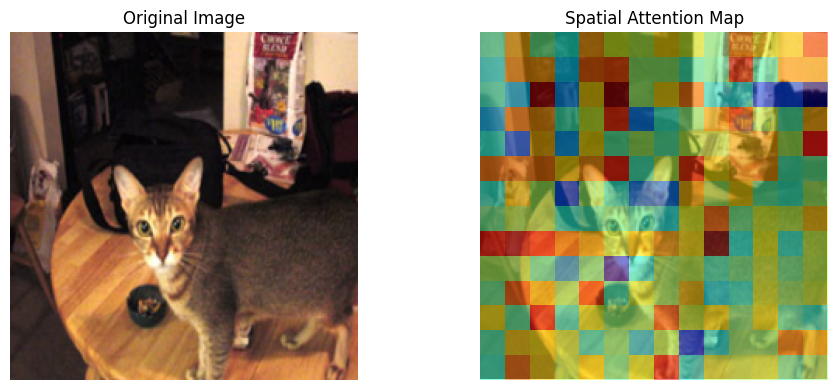

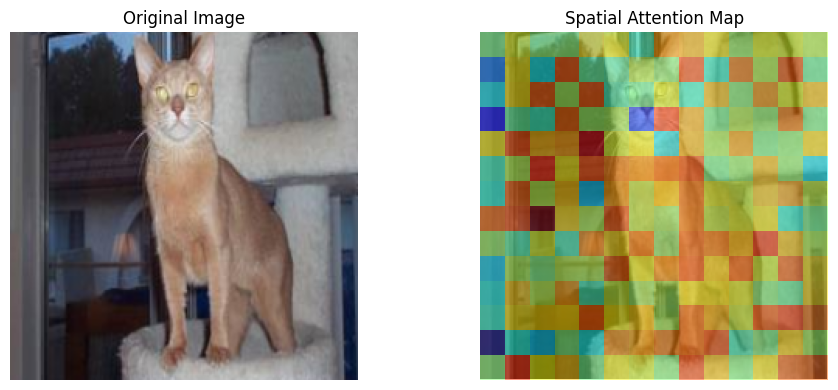

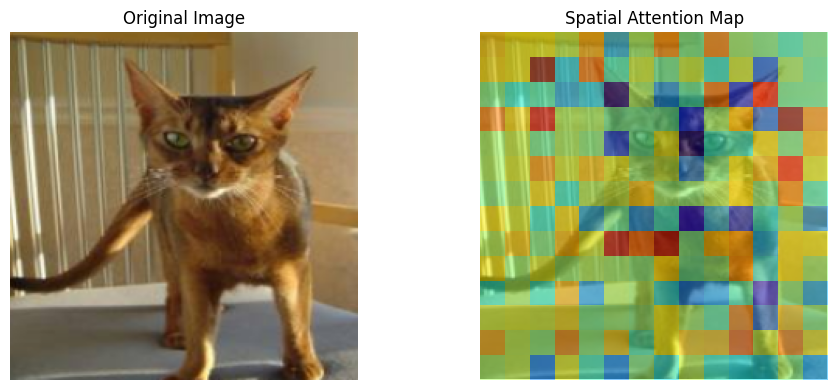

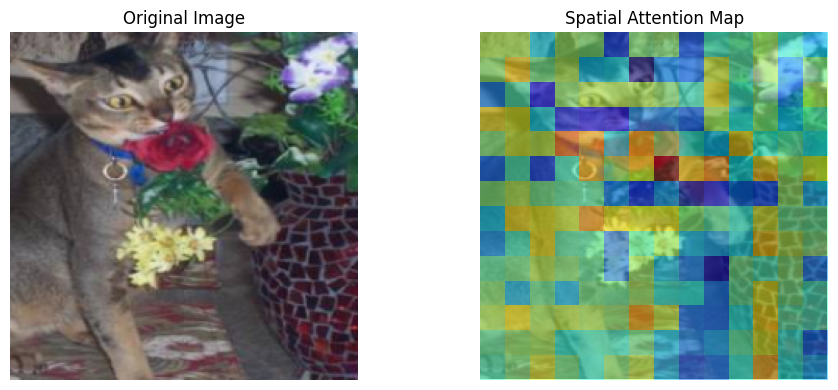

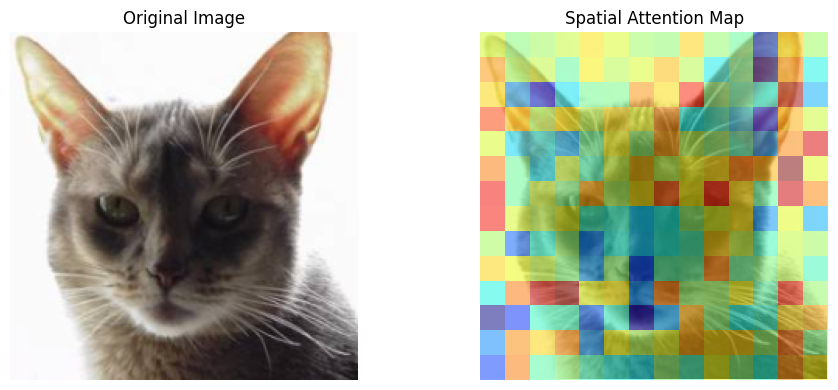

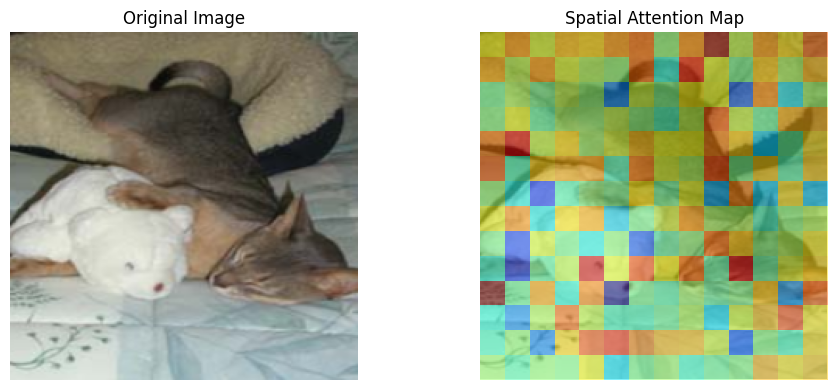

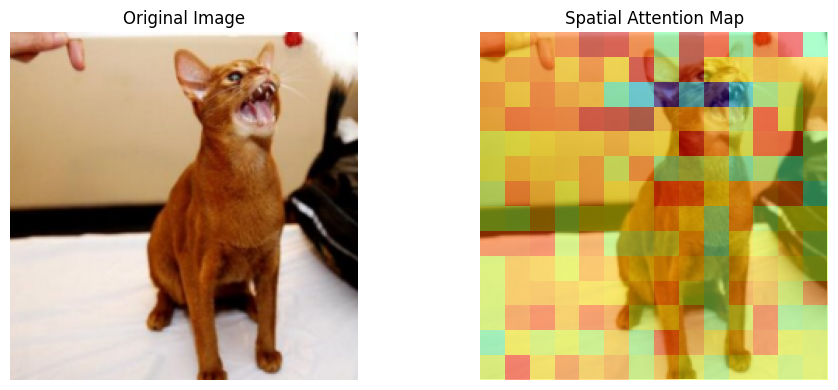

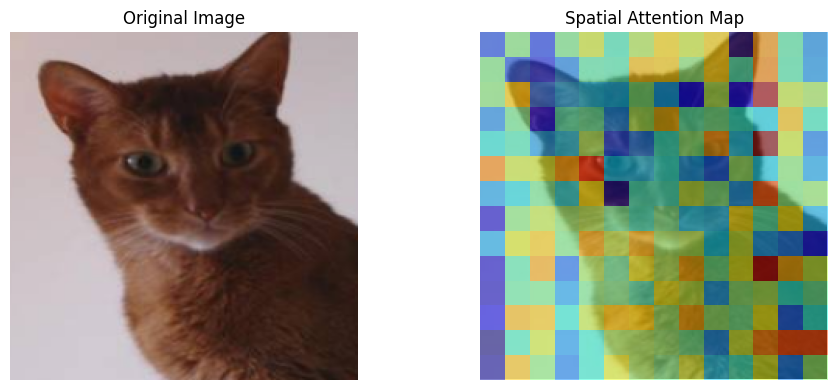

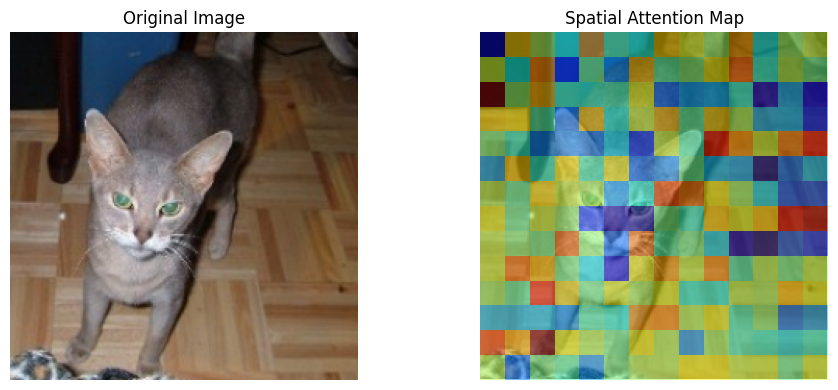

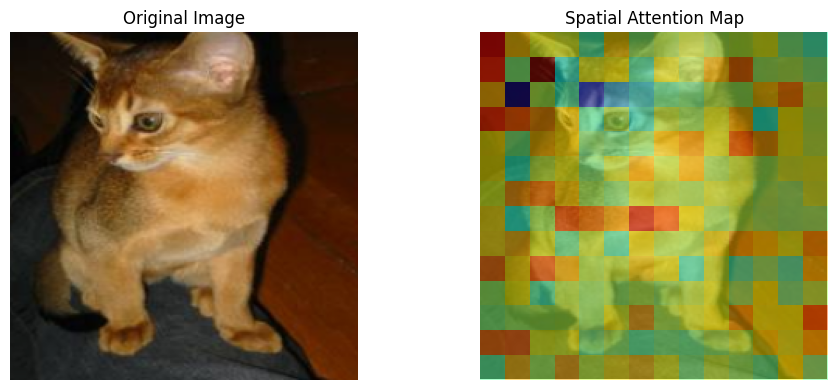

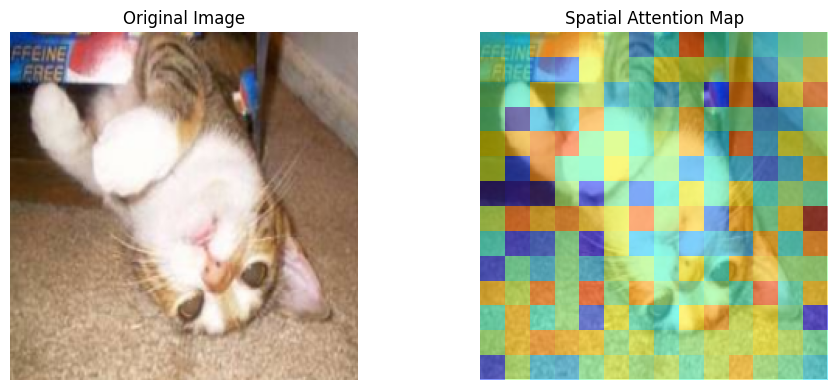

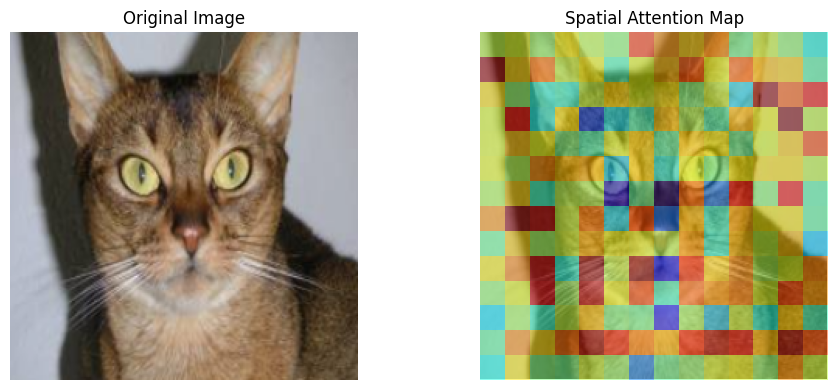

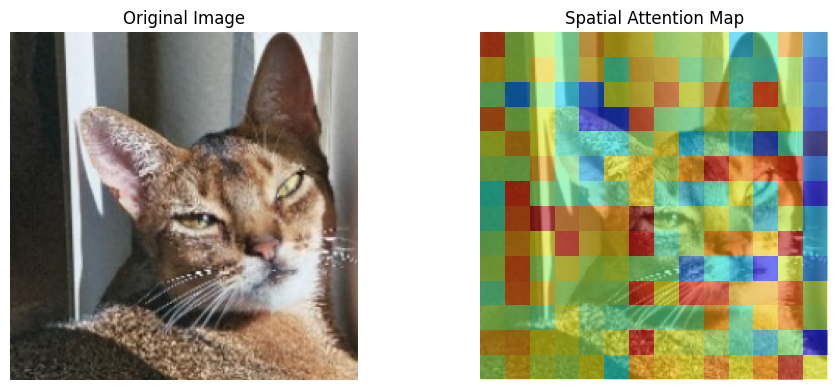

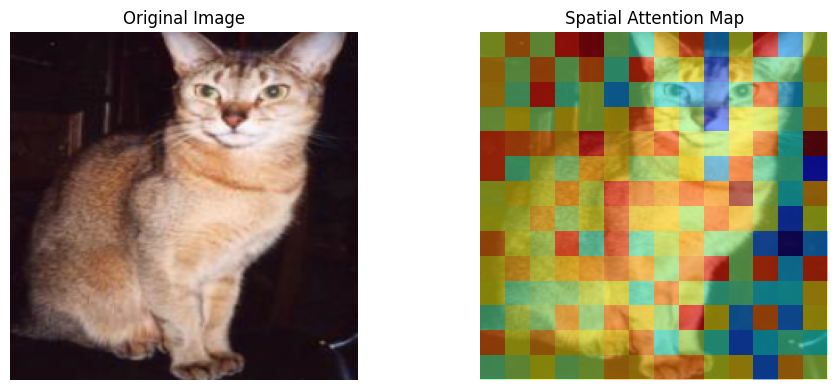

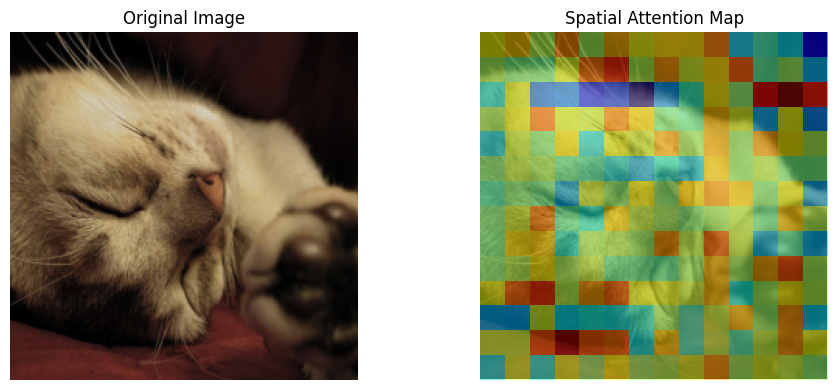

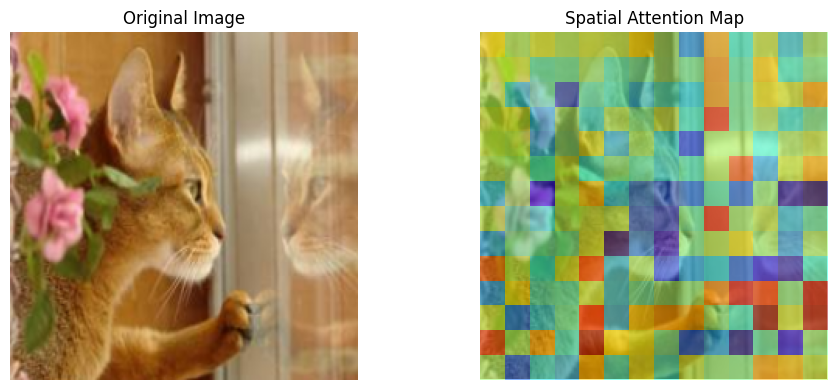

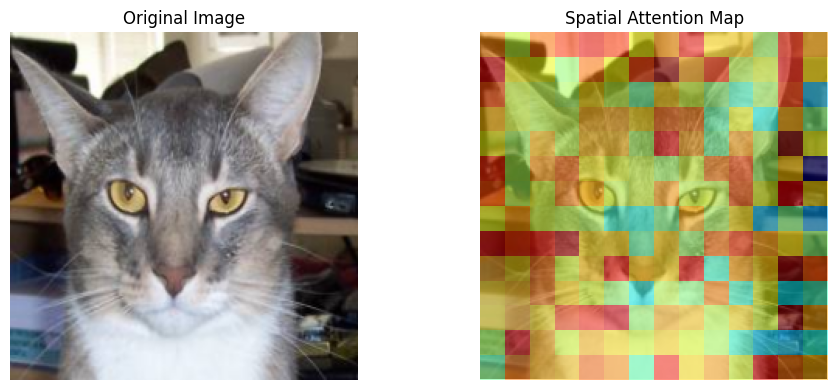

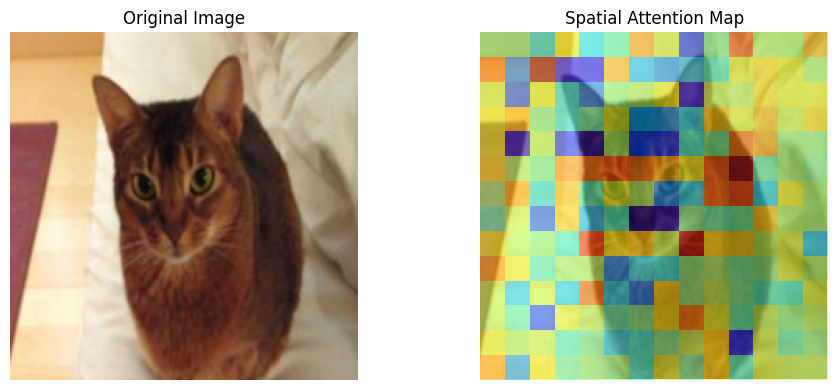

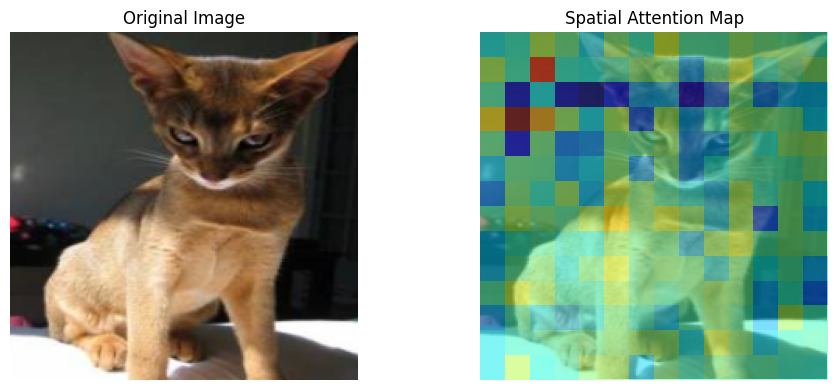

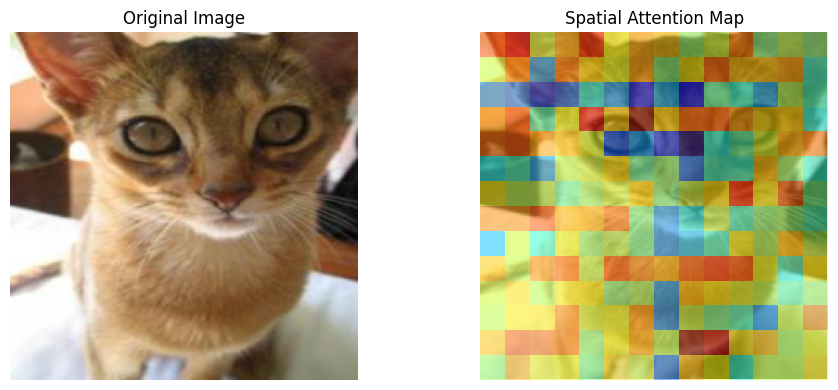

In [74]:
images, labels = next(iter(val_loader))
for i in range(20):
  img = images[i].to(device)
  get_attention_map(model, img)

        # take first image in batch

# Get attention map
